# Mlearn 510 - Lesson 01
### Social network advertising, also social media targeting, is a group of terms that are used to describe forms of online advertising/digital marketing that focus on social networking services. One of the major benefits of this type of advertising is that advertisers can take advantage of the users' demographic information and target their ads appropriately.

### Social media targeting combines current targeting options (such as geotargeting, behavioral targeting, socio-psychographic targeting, etc.), to make detailed target group identification possible. With social media targeting, advertisements are distributed to users based on information gathered from target group profiles.

### Social network advertising is not necessarily the same as social media targeting. Social media targeting is a method of optimizing social media advertising by using profile data to deliver advertisements directly to individual users. Social network advertising refers to the process of matching social network users to target groups that have been specified by the advertiser. Social media advertising involves creating content on social media platforms, engaging with followers, and running social media advertisements.

#### Source: [Wikipedia](https://en.wikipedia.org/wiki/Social_network_advertising)

## For this assignment, we will take a look at how Social Network pick who to advertise using k-Nearest Neighbor algorithm. We will leverage the [Social Network Ads dataset](https://www.kaggle.com/rakeshrau/social-network-ads).

## First, let's import the data

# Learning Objectives
- Define basic terminology of machine learning.
- Describe a typical machine learning modeling process.
- Demonstrate the ability to use K-Nearest Neighbor algorithm.
- Demonstrate the ability to tweak K-Nearest Neighbor algorithm.
- Demonstrate the ability to determine the accuracy of a model.

In [1]:
import numpy as np
import pandas as pd
pd.__version__
SNA = pd.read_csv('./Social_Network_Ads.csv')

## Question 1: Print the top 10 rows of the dataset

In [2]:
print(SNA[0:10])

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
5  15728773    Male   27            58000          0
6  15598044  Female   27            84000          0
7  15694829  Female   32           150000          1
8  15600575    Male   25            33000          0
9  15727311  Female   35            65000          0


## Question 1.2: Drop the User Id column from the SNA dataframe using [drop](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html) method

In [3]:
SNA = SNA.drop(columns=["User ID"])

## Question 2.1: Within the Gender column, replace the text Male and Female with 0 and 1 respectively. You can use [replace](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.replace.html) method.

In [4]:
SNA = SNA.replace({"Gender": {"Male": 0, "Female": 1}})

## Question 2.2: Check if successful by printing top 10 rows

In [5]:
SNA[0:10]

,Gender,Age,EstimatedSalary,Purchased
0,0,19,19000,0
1,0,35,20000,0
2,1,26,43000,0
3,1,27,57000,0
4,0,19,76000,0
5,0,27,58000,0
6,1,27,84000,0
7,1,32,150000,1
8,0,25,33000,0
9,1,35,65000,0


## As part of any machine learning problem, we need to explore the data and perform exploratory data analysis. For the next set of questions, we will be using [seaborn](https://seaborn.pydata.org/index.html) library for visualization.

## Question 3.1: Using Seaboard [scatterplot](https://seaborn.pydata.org/generated/seaborn.scatterplot.html), create three pairwise scatter plots using Purchased column as hue for the following pairs:
### 1. Age & EstimatedSalary
### 2. Age & Gender
### 3. Gender & EstimatedSalary

In [6]:
import seaborn as sns
sns.set(font_scale=1.2)
sns.__version__ 

'0.11.0'

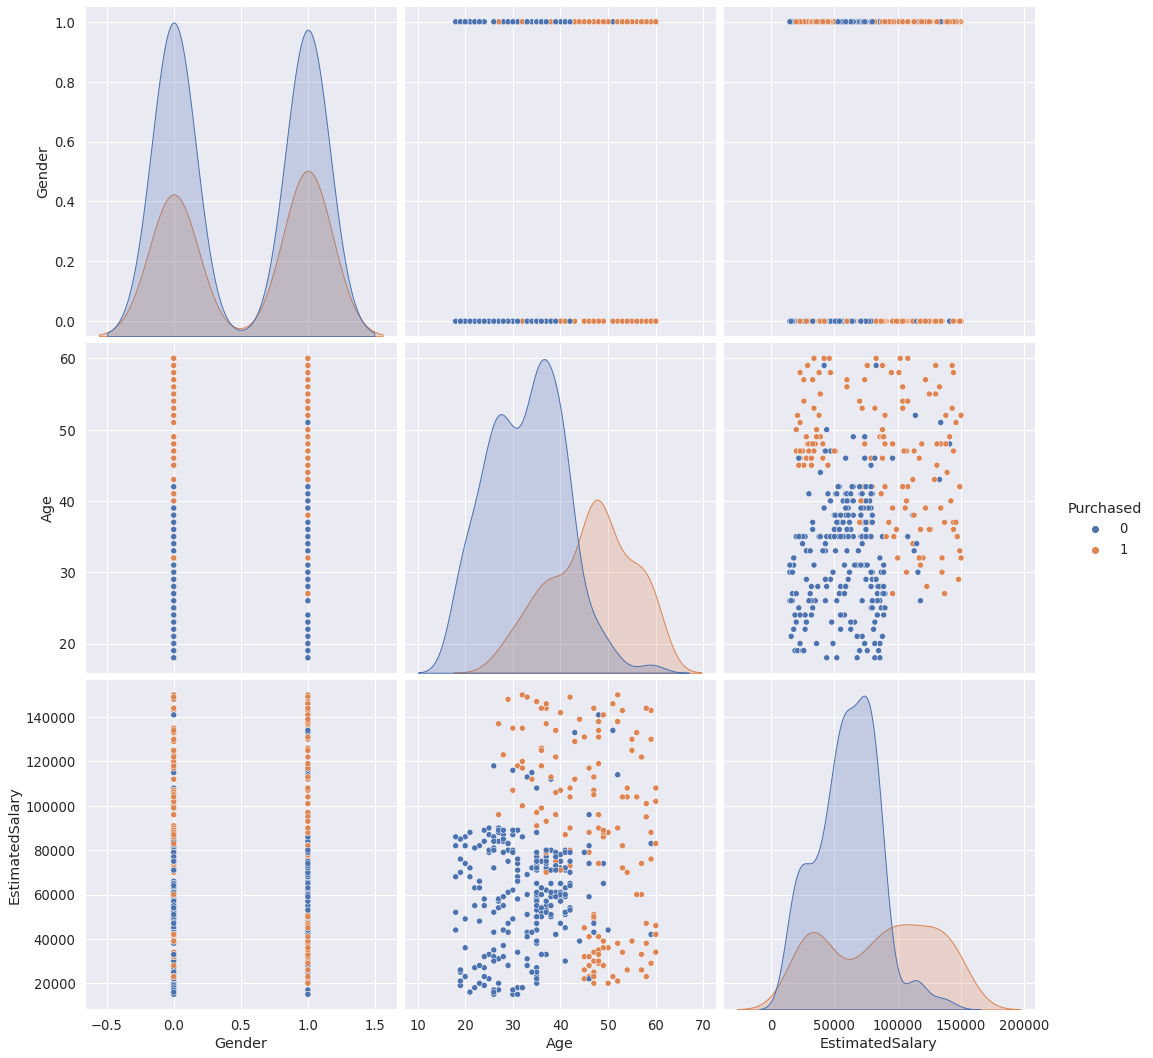

In [7]:
sns.pairplot(SNA, hue="Purchased", height=5);

## Question 3.2: Based on the above plots, which feature(s) can be best used to determine if a person will purchase an item based on Ad? 

## The features that can be best used to determine whether or not a person would purchase the product are both Age and Estimated Salary; this can best be seen by setting the hue to the Purchased feature and then examining the Age vs Estimated Salary scatter plot, as well as the two histograms for each of the features. 

## Question 3.3: Use histogram plots to validate your answer. Set the Hue to be 'Purchased'

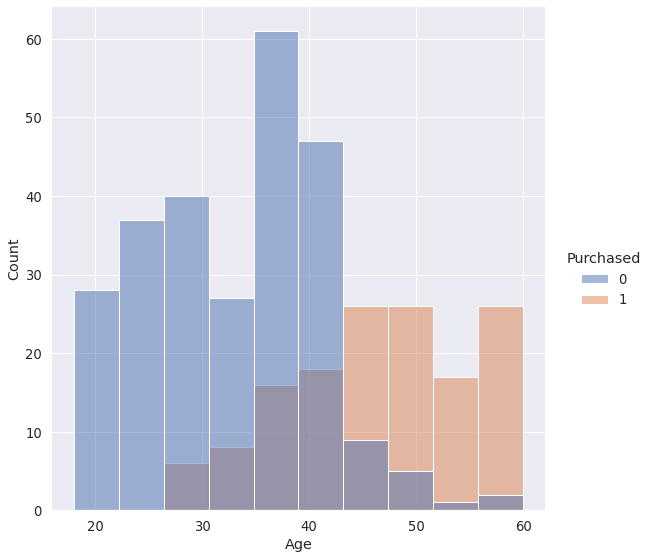

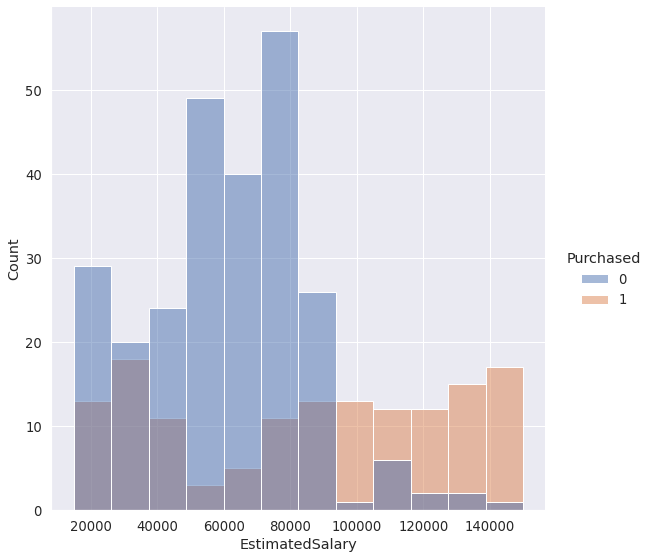

In [8]:
sns.displot(SNA, x=SNA.Age, hue="Purchased", height=8),sns.displot(SNA, x=SNA.EstimatedSalary, hue="Purchased", height=8);

## Question 4: Now that we have performed data exploration, lets experiment with k-NN algorithm. But first, we need to split the data into training and testing set. To perform this task, you can use [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to create a 70/30 split for training and test data respectively.

In [9]:
from sklearn.model_selection import train_test_split
X = np.asarray(SNA).reshape(-1, 4)
y = np.asarray(SNA["Purchased"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

## Question 5.1: Using [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), write a k-NN classifier with n=2

In [10]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=2);

## Using [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html), [confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html), evaluate and print the classifier output

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
neigh.fit(X_train, y_train)
y_true, y_pred =  np.array(y_train), neigh.predict(X_train) #Using training data for classification report.
print("k value:",2)
print(classification_report(y_true, y_pred))
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("accuracy:",accuracy_score(y_true, y_pred)*100,"%")

k value: 2
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       178
           1       1.00      0.70      0.82       102

    accuracy                           0.89       280
   macro avg       0.93      0.85      0.87       280
weighted avg       0.91      0.89      0.88       280

confusion matrix:
 [[178   0]
 [ 31  71]]
accuracy: 88.92857142857142 %


## Question 5.2: What happens when you increase the value of k from 2 to 10. Iterate over k from 2 to 10, build and evaluate the different KNeighborsClassifier

###  It seems that the perfomance of the classfier may be increased by finding a k value that best suits the dataset (specifically for the testing dataset, not the training dataset, see graph under Question 6.3); it also appears to present an drawback because as k increases, the accuracy inevitably suffers no matter what dataset is used.

In [12]:
for i in range(3,11):
    neigh = KNeighborsClassifier(n_neighbors=i)
    neigh.fit(X_train, y_train)
    y_true, y_pred = np.array(y_train), neigh.predict(X_train) #Using training data for classification report.
    print("k value:",i)
    print(classification_report(y_true, y_pred))
    print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
    print("accuracy:",accuracy_score(y_true, y_pred)*100,"%")
    print()

k value: 3
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       178
           1       0.86      0.81      0.84       102

    accuracy                           0.89       280
   macro avg       0.88      0.87      0.87       280
weighted avg       0.89      0.89      0.88       280

confusion matrix:
 [[165  13]
 [ 19  83]]
accuracy: 88.57142857142857 %

k value: 4
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       178
           1       0.91      0.68      0.78       102

    accuracy                           0.86       280
   macro avg       0.87      0.82      0.84       280
weighted avg       0.86      0.86      0.85       280

confusion matrix:
 [[171   7]
 [ 33  69]]
accuracy: 85.71428571428571 %

k value: 5
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       178
           1       0.85      0.77      0.81       102

   

## Question 5.3: What happened to the accuracy of the classifier at k>9 and why?

### It seems the accuracy suffers as the k value increases due to the classifier model overfitting the data, resulting in an increasingly inaccurate classification of the testing data.

In [13]:
neigh = KNeighborsClassifier(n_neighbors=40)
neigh.fit(X_train, y_train)
y_true, y_pred = np.array(y_train), neigh.predict(X_train) #Using training data for classification report.
print("k value:",40)
print(classification_report(y_true, y_pred))
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("accuracy:",accuracy_score(y_true, y_pred)*100,"%")

k value: 40
              precision    recall  f1-score   support

           0       0.77      0.94      0.84       178
           1       0.82      0.50      0.62       102

    accuracy                           0.78       280
   macro avg       0.79      0.72      0.73       280
weighted avg       0.79      0.78      0.76       280

confusion matrix:
 [[167  11]
 [ 51  51]]
accuracy: 77.85714285714286 %


## Question 6.1: Now try eliminating one of the features (Gender) from the dataset

In [14]:
SNA = SNA.drop(columns=["Gender"])
X = np.asarray(SNA).reshape(-1, 3)
y = np.asarray(SNA["Purchased"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
neigh = KNeighborsClassifier(n_neighbors=2)
neigh.fit(X_train, y_train)
y_true, y_pred = np.array(y_train), neigh.predict(X_train) #Using training data for classification report.
print("k value:",2)
print(classification_report(y_true, y_pred))
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("accuracy:",accuracy_score(y_true, y_pred)*100,"%")

k value: 2
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       176
           1       1.00      0.65      0.79       104

    accuracy                           0.87       280
   macro avg       0.92      0.83      0.85       280
weighted avg       0.89      0.87      0.86       280

confusion matrix:
 [[176   0]
 [ 36  68]]
accuracy: 87.14285714285714 %


## Question 6.2: Perform the same task from question 5.2 with the updated data

In [15]:
for i in range(2,11):
    neigh = KNeighborsClassifier(n_neighbors=i)
    neigh.fit(X_train, y_train)
    y_true, y_pred =  np.array(y_train), neigh.predict(X_train) #Using training data for classification report.
    print("k value:",i)
    print(classification_report(y_true, y_pred))
    print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
    print("accuracy:",accuracy_score(y_true, y_pred)*100,"%")
    print()

k value: 2
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       176
           1       1.00      0.65      0.79       104

    accuracy                           0.87       280
   macro avg       0.92      0.83      0.85       280
weighted avg       0.89      0.87      0.86       280

confusion matrix:
 [[176   0]
 [ 36  68]]
accuracy: 87.14285714285714 %

k value: 3
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       176
           1       0.88      0.81      0.84       104

    accuracy                           0.89       280
   macro avg       0.89      0.87      0.88       280
weighted avg       0.89      0.89      0.89       280

confusion matrix:
 [[165  11]
 [ 20  84]]
accuracy: 88.92857142857142 %

k value: 4
              precision    recall  f1-score   support

           0       0.83      0.97      0.89       176
           1       0.92      0.65      0.76       104

   

In [16]:
neigh = KNeighborsClassifier(n_neighbors=40)
neigh.fit(X_train, y_train)
y_true, y_pred = np.array(y_train), neigh.predict(X_train) #Using training data for classification report.
print("k value:",40)
print(classification_report(y_true, y_pred))
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("accuracy:",accuracy_score(y_true, y_pred)*100,"%")

k value: 40
              precision    recall  f1-score   support

           0       0.77      0.94      0.84       176
           1       0.83      0.52      0.64       104

    accuracy                           0.78       280
   macro avg       0.80      0.73      0.74       280
weighted avg       0.79      0.78      0.77       280

confusion matrix:
 [[165  11]
 [ 50  54]]
accuracy: 78.21428571428571 %


## Question 6.3: What happened to the results? What's your conclusion? Plot accuracy vs k.

### Building off of what I concluded before; It appears that accuracy suffers as the k value increases due to the classifier model overfitting the data, especially when classifying the training data itself. All of this results in an increasingly inaccurate classification of the inputted dataset. If I had to pick a k value to use with the testing data with the goal of maximizing performance I would use a value between 2 and 25, the reason is the accuracy of both datasets in this interval are far greater than those found at larger values of k. It seems that using a accuracy vs k plot for a given dataset when applying the KNN algorithm is a viable way of quickly identifying the range of k values that work best.

In [17]:
def KNN_accuracy_score(k,X,y):
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X_train, y_train)
    y_true, y_pred = np.array(y), neigh.predict(X)
    return accuracy_score(y_true, y_pred)

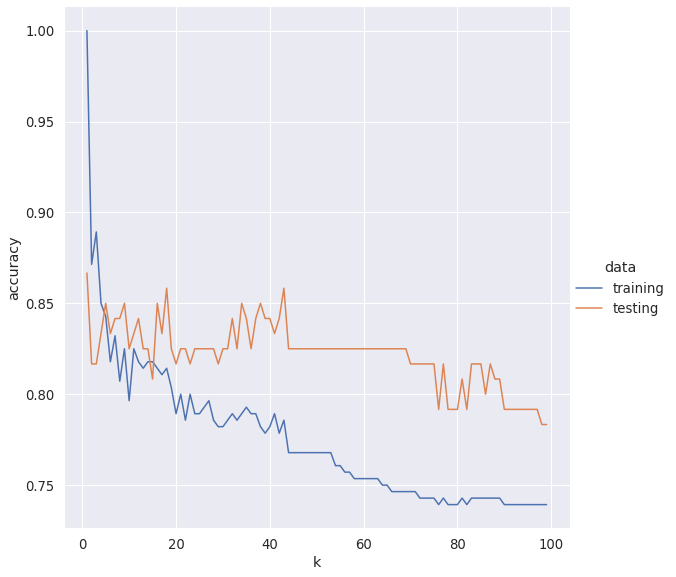

In [18]:
k = np.arange(1,100)
trainscore = [KNN_accuracy_score(n,X_train, y_train) for n in k]
traindf = pd.DataFrame(data={'k': k, 'accuracy':trainscore, 'data':"training"})
testscore = [KNN_accuracy_score(n,X_test, y_test) for n in k]
testdf = pd.DataFrame(data={'k': k, 'accuracy':testscore, 'data':"testing"})
mink = pd.concat([traindf,testdf])
sns.relplot(data=mink, x='k', y='accuracy', kind="line", hue='data', height=8);

## Question 7: Repeat steps 6.1-6.3 with another distance metric. Comment on what happens to the results?

### After browsing the various available distance metrics that could be used instead of the minkowski metric I used the braycurtis metric, after performing the same tasks I found the difference in performance is minimal and both metrics appear to perform at comprable levels in terms of accuracy. Their accuracy with increasing values of k also appear to be comprable which leads me to believe either is a vaiable distance metric for this context.

In [19]:
neigh = KNeighborsClassifier(n_neighbors=2, metric="braycurtis")
neigh.fit(X_train, y_train)
y_true, y_pred = np.array(y_test), neigh.predict(X_test)
print("k value:",2)
print(classification_report(y_true, y_pred))
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("accuracy:",accuracy_score(y_true, y_pred)*100,"%")

k value: 2
              precision    recall  f1-score   support

           0       0.79      0.95      0.87        81
           1       0.83      0.49      0.61        39

    accuracy                           0.80       120
   macro avg       0.81      0.72      0.74       120
weighted avg       0.80      0.80      0.78       120

confusion matrix:
 [[77  4]
 [20 19]]
accuracy: 80.0 %


## Question 7.2: Perform the same task from question 5.2 with the updated data

In [20]:
neigh = KNeighborsClassifier(n_neighbors=10, metric="braycurtis")
neigh.fit(X_train, y_train)
y_true, y_pred = np.array(y_test), neigh.predict(X_test)
print("k value:",i)
print(classification_report(y_true, y_pred))
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("accuracy:",accuracy_score(y_true, y_pred)*100,"%")

              precision    recall  f1-score   support

           0       0.74      0.89      0.81        76
           1       0.71      0.45      0.56        44

    accuracy                           0.73       120
   macro avg       0.73      0.67      0.68       120
weighted avg       0.73      0.73      0.72       120

confusion matrix:
 [[68  8]
 [24 20]]
accuracy: 73.33333333333333 %


In [20]:
for i in range(2,11):
    neigh = KNeighborsClassifier(n_neighbors=i, metric="braycurtis")
    neigh.fit(X_train, y_train)
    y_true, y_pred =  np.array(y_train), neigh.predict(X_train) #Using training data for classification report.
    print("k value:",i)
    print(classification_report(y_true, y_pred))
    print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
    print("accuracy:",accuracy_score(y_true, y_pred)*100,"%")
    print()

k value: 2
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       176
           1       1.00      0.68      0.81       104

    accuracy                           0.88       280
   macro avg       0.92      0.84      0.86       280
weighted avg       0.90      0.88      0.88       280

confusion matrix:
 [[176   0]
 [ 33  71]]
accuracy: 88.21428571428571 %

k value: 3
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       176
           1       0.89      0.81      0.85       104

    accuracy                           0.89       280
   macro avg       0.89      0.88      0.88       280
weighted avg       0.89      0.89      0.89       280

confusion matrix:
 [[166  10]
 [ 20  84]]
accuracy: 89.28571428571429 %

k value: 4
              precision    recall  f1-score   support

           0       0.82      0.95      0.88       176
           1       0.89      0.65      0.76       104

   

In [21]:
neigh = KNeighborsClassifier(n_neighbors=40, metric="braycurtis")
neigh.fit(X_train, y_train)
y_true, y_pred = np.array(y_test), neigh.predict(X_test)
print("k value:",i)
print(classification_report(y_true, y_pred))
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("accuracy:",accuracy_score(y_true, y_pred)*100,"%")

k value: 10
              precision    recall  f1-score   support

           0       0.80      0.99      0.88        81
           1       0.95      0.49      0.64        39

    accuracy                           0.82       120
   macro avg       0.88      0.74      0.76       120
weighted avg       0.85      0.82      0.81       120

confusion matrix:
 [[80  1]
 [20 19]]
accuracy: 82.5 %


In [22]:
def KNN_accuracy_score(k,X,y):
    neigh = KNeighborsClassifier(n_neighbors=k, metric="braycurtis")
    neigh.fit(X_train, y_train)
    y_true, y_pred = np.array(y), neigh.predict(X)
    return accuracy_score(y_true, y_pred)

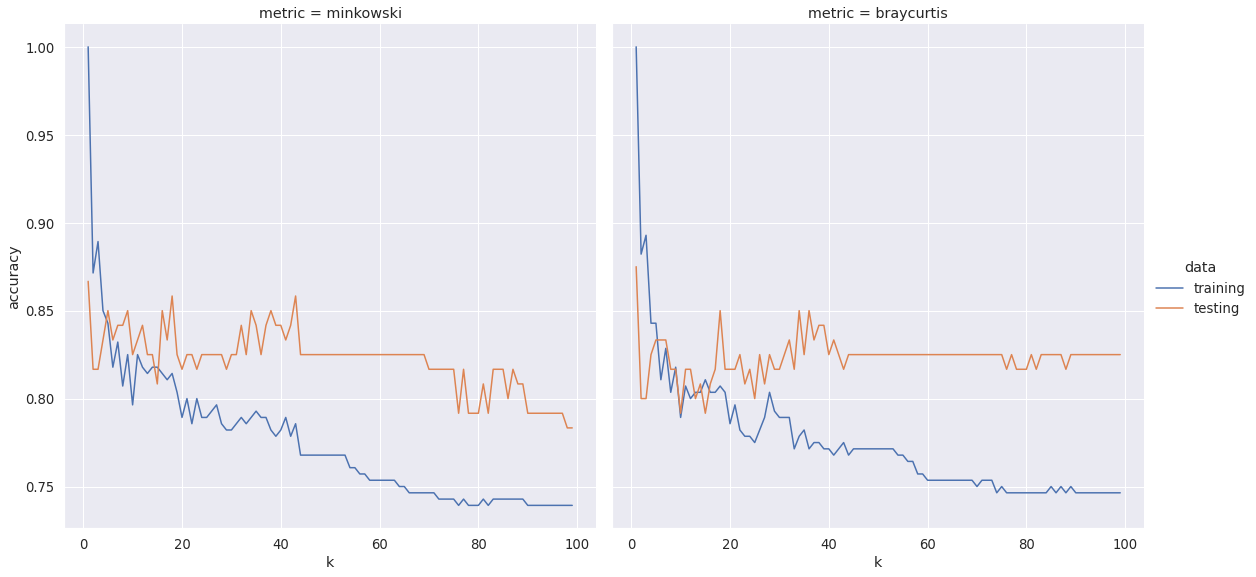

In [23]:
traindf = pd.DataFrame(data={'k': k, 'accuracy':trainscore, 'data':"training"})
testdf = pd.DataFrame(data={'k': k, 'accuracy':testscore, 'data':"testing"})
mink = pd.concat([traindf,testdf])
mink["metric"]="minkowski"

trainscore = [KNN_accuracy_score(n,X_train, y_train) for n in k]
traindf = pd.DataFrame(data={'k': k, 'accuracy':trainscore, 'data':"training"})
testscore = [KNN_accuracy_score(n,X_test, y_test) for n in k]
testdf = pd.DataFrame(data={'k': k, 'accuracy':testscore, 'data':"testing"})
bray = pd.concat([traindf,testdf])
bray["metric"]="braycurtis"

sns.relplot(data=pd.concat([mink,bray]), x='k', y='accuracy', hue="data", col="metric", kind="line", height=8);